# 05 — MLlib Ensemble (RandomForest + GBT)

Train and evaluate a Random Forest and Gradient Boosted Tree ensemble on the
assembled Parquet from notebook 04.  
Target: `ndvi_anomaly_harvest` — seasonal NDVI deviation from vineyard mean.


In [1]:
import os
os.environ.setdefault('JAVA_HOME', '/usr/lib/jvm/java-17-openjdk-amd64')
os.environ['PYSPARK_PYTHON']        = '/home/simonhans/anaconda3/envs/GrapeExpectationsML/bin/python'
os.environ['PYSPARK_DRIVER_PYTHON'] = '/home/simonhans/anaconda3/envs/GrapeExpectationsML/bin/python'

PARQUET   = '../data/spark/assembled_v2'
MODEL_DIR = '../data/spark/models_v2'
os.makedirs(MODEL_DIR, exist_ok=True)

In [2]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
    .appName('GrapeExpectations-v2-ML')
    .master('local[*]')
    .config('spark.driver.memory', '10g')
    .config('spark.driver.maxResultSize', '2g')
    .config('spark.sql.shuffle.partitions', '200')
    .getOrCreate())

spark.sparkContext.setLogLevel('WARN')
print('Spark version:', spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/18 22:10:15 WARN Utils: Your hostname, sbook, resolves to a loopback address: 127.0.1.1; using 192.168.86.191 instead (on interface wlp2s0)
26/08/18 22:10:15 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/18 22:10:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


In [3]:
from pyspark.sql import functions as F

df = spark.read.parquet(PARQUET)
print(f'Loaded: {df.count():,} rows x {len(df.columns)} cols')

TARGET = 'ndvi_anomaly_harvest'

# v1 uses all pre-harvest weeks 1-35 (harvest = weeks 36-43)
feature_wks = list(range(1, 36))

# v1 feature set: slope + std capture phenological rate and variability
# smooth_mean excluded (spatial autocorrelation with harvest-window NDVI)
feat_slope_cols = [f'{w}_ndvi_smooth_slope' for w in feature_wks
                   if f'{w}_ndvi_smooth_slope' in df.columns]
feat_std_cols   = [f'{w}_ndvi_smooth_std'   for w in feature_wks
                   if f'{w}_ndvi_smooth_std'   in df.columns]
feat_mean_cols  = [f'{w}_ndvi_smooth_mean'  for w in feature_wks
                   if f'{w}_ndvi_smooth_mean'  in df.columns]

# Climate: growing-season weeks 28-43 (vineyard-wide signal — not leakage)
climate_prefixes = [
    'ppt_', 'tmax_', 'tmin_', 'tmean_', 'vpdmax_', 'vpdmin_', 'cumulative_gdd_',
    'water_availability_', 'diurnal_temp_range_', 'stress_index',
]
climate_cols = [c for c in df.columns
                if any(c.startswith(p) for p in climate_prefixes)]

terrain_cols = [c for c in df.columns if any(k in c for k in [
    'elev_', 'slope_', 'aspect_', 'curvature_', 'profile_curv', 'plan_curv',
    'elev_dev', 'local_relief', 'total_relief',
])]

soil_cols = [c for c in df.columns if any(c.startswith(k) for k in [
    'sandtotal', 'silttotal', 'claytotal', 'awc_', 'cec7', 'om_r', 'ph1to1', 'ec_r',
    'profile_depth', 'max_depth', 'frag', 'dbovendry', 'caco3', 'drain', 'restriction',
])]

feature_cols = list(dict.fromkeys(
    feat_slope_cols + feat_std_cols + climate_cols + terrain_cols + soil_cols
))

print(f'Features: {len(feature_cols)} total')
print(f'  NDVI slope wks 1-35 : {len(feat_slope_cols)}')
print(f'  NDVI std wks 1-35   : {len(feat_std_cols)}')
print(f'  Climate wks 28-43   : {len(climate_cols)}')
print(f'  Terrain             : {len(terrain_cols)}')
print(f'  Soil                : {len(soil_cols)}')

Loaded: 330,280 rows x 419 cols
Features: 271 total
  NDVI slope wks 1-35 : 35
  NDVI std wks 1-35   : 35
  Climate wks 28-43   : 160
  Terrain             : 25
  Soil                : 16


In [4]:
# Drop rows with null target only — Imputer handles null features downstream
df_ml = df.select(feature_cols + [TARGET]).dropna(subset=[TARGET])
print(f'Rows after dropna: {df_ml.count():,}')

Rows after dropna: 330,280


In [5]:
from pyspark.ml.feature import VectorAssembler, Imputer
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

imputer = Imputer(inputCols=feature_cols, outputCols=[f'{c}_imp' for c in feature_cols])

assembler = VectorAssembler(
    inputCols=[f'{c}_imp' for c in feature_cols],
    outputCol='features'
)

evaluator = RegressionEvaluator(labelCol=TARGET, predictionCol='prediction', metricName='r2')
rmse_eval = RegressionEvaluator(labelCol=TARGET, predictionCol='prediction', metricName='rmse')

train, test = df_ml.randomSplit([0.8, 0.2], seed=42)
train = train.cache()
print(f'Train: {train.count():,}  Test: {test.count():,}')

26/08/18 22:10:26 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Train: 264,543  Test: 65,737


In [6]:
rf = RandomForestRegressor(
    featuresCol='features',
    labelCol=TARGET,
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_pipeline = Pipeline(stages=[imputer, assembler, rf])

print('Training RF…')
rf_model = rf_pipeline.fit(train)

Training RF…


26/08/18 22:14:38 WARN DAGScheduler: Broadcasting large task binary with size 1334.0 KiB
26/08/18 22:15:52 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/08/18 22:17:12 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/08/18 22:18:26 WARN DAGScheduler: Broadcasting large task binary with size 4.7 MiB
26/08/18 22:19:08 WARN DAGScheduler: Broadcasting large task binary with size 4.8 MiB
26/08/18 22:19:29 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
26/08/18 22:19:42 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
26/08/18 22:19:56 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB
26/08/18 22:20:14 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
26/08/18 22:20:27 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
26/08/18 22:20:57 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
26/08/18 22:21:17 WARN DAGScheduler: Broadcasting l

In [7]:
rf_preds = rf_model.transform(test)
rf_r2   = evaluator.evaluate(rf_preds)
rf_rmse = rmse_eval.evaluate(rf_preds)
print(f'RF  Test R²={rf_r2:.4f}  RMSE={rf_rmse:.5f}')

RF  Test R²=0.8181  RMSE=0.04165


In [8]:
gbt = GBTRegressor(
    featuresCol='features',
    labelCol=TARGET,
    maxIter=100,
    maxDepth=6,
    seed=42
)

gbt_pipeline = Pipeline(stages=[imputer, assembler, gbt])

print('Training GBT…')
gbt_model = gbt_pipeline.fit(train)

Training GBT…


26/08/18 22:24:21 WARN DAGScheduler: Broadcasting large task binary with size 1000.3 KiB
26/08/18 22:24:22 WARN DAGScheduler: Broadcasting large task binary with size 1002.7 KiB
26/08/18 22:24:22 WARN DAGScheduler: Broadcasting large task binary with size 1007.3 KiB
26/08/18 22:24:22 WARN DAGScheduler: Broadcasting large task binary with size 1010.5 KiB
26/08/18 22:24:23 WARN DAGScheduler: Broadcasting large task binary with size 1010.9 KiB
26/08/18 22:24:23 WARN DAGScheduler: Broadcasting large task binary with size 1011.5 KiB
26/08/18 22:24:23 WARN DAGScheduler: Broadcasting large task binary with size 1012.7 KiB
26/08/18 22:24:23 WARN DAGScheduler: Broadcasting large task binary with size 1015.0 KiB
26/08/18 22:24:24 WARN DAGScheduler: Broadcasting large task binary with size 1019.6 KiB
26/08/18 22:24:24 WARN DAGScheduler: Broadcasting large task binary with size 1023.0 KiB
26/08/18 22:24:24 WARN DAGScheduler: Broadcasting large task binary with size 1023.5 KiB
26/08/18 22:24:25 WAR

In [9]:
gbt_preds = gbt_model.transform(test)
gbt_r2   = evaluator.evaluate(gbt_preds)
gbt_rmse = rmse_eval.evaluate(gbt_preds)
print(f'GBT Test R²={gbt_r2:.4f}  RMSE={gbt_rmse:.5f}')

GBT Test R²=0.8950  RMSE=0.03164


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

importances = rf_model.stages[-1].featureImportances.toArray()
feat_imp = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

cats = {
    'NDVI slope (wks 1-35)': feat_slope_cols,
    'NDVI std  (wks 1-35)':  feat_std_cols,
    'NDVI mean (wks 1-35)':  feat_mean_cols,
    'Climate (wks 28-43)':   climate_cols,
    'Terrain':               terrain_cols,
    'Soil':                  soil_cols,
}

print('Feature importance by group:')
for cat, cols in cats.items():
    total = feat_imp.loc[feat_imp['feature'].isin(cols), 'importance'].sum()
    print(f'  {cat:26s}: {total*100:.1f}%')

print()
print('Top 15 features:')
print(feat_imp.head(15).to_string(index=False))

Feature importance by group:
  NDVI slope (wks 1-35)     : 61.0%
  NDVI std  (wks 1-35)      : 15.8%
  NDVI mean (wks 1-35)      : 0.0%
  Climate (wks 28-43)       : 9.1%
  Terrain                   : 10.0%
  Soil                      : 4.1%

Top 15 features:
             feature  importance
19_ndvi_smooth_slope    0.130203
23_ndvi_smooth_slope    0.062066
20_ndvi_smooth_slope    0.055457
35_ndvi_smooth_slope    0.040909
21_ndvi_smooth_slope    0.037818
27_ndvi_smooth_slope    0.035276
22_ndvi_smooth_slope    0.031217
25_ndvi_smooth_slope    0.030863
24_ndvi_smooth_slope    0.029180
18_ndvi_smooth_slope    0.026181
             slope_x    0.023118
34_ndvi_smooth_slope    0.019911
33_ndvi_smooth_slope    0.018213
  22_ndvi_smooth_std    0.016860
14_ndvi_smooth_slope    0.014438


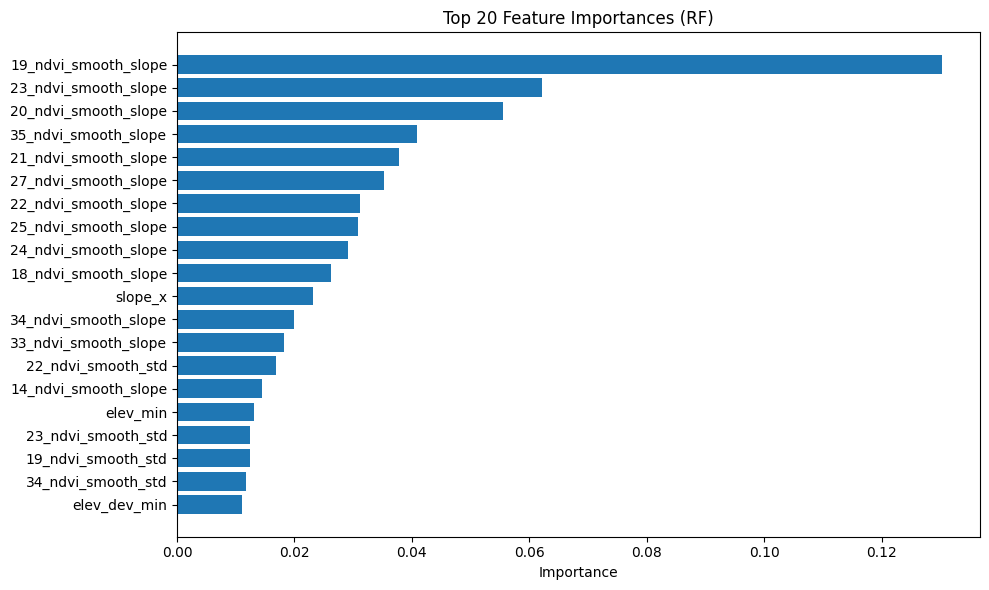

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
top = feat_imp.head(20)
ax.barh(top['feature'][::-1], top['importance'][::-1])
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importances (RF)')
plt.tight_layout()
plt.savefig('../data/spark/feature_importances.png', dpi=150)
plt.show()


In [12]:
rf_model.write().overwrite().save(os.path.join(MODEL_DIR, 'rf'))
gbt_model.write().overwrite().save(os.path.join(MODEL_DIR, 'gbt'))

print(f'Models saved to {MODEL_DIR}/')
print(f'\nFinal summary:')
print(f'  RF  R²={rf_r2:.4f}  RMSE={rf_rmse:.5f}')
print(f'  GBT R²={gbt_r2:.4f}  RMSE={gbt_rmse:.5f}')

26/08/18 22:26:00 WARN TaskSetManager: Stage 1290 contains a task of very large size (4789 KiB). The maximum recommended task size is 1000 KiB.


Models saved to ../data/spark/models_v2/

Final summary:
  RF  R²=0.8181  RMSE=0.04165
  GBT R²=0.8950  RMSE=0.03164
